In [57]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW 
from torch.optim.lr_scheduler import LinearLR, SequentialLR, ConstantLR  
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback,
    DataCollatorWithPadding)
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
from datetime import datetime
from datasets import Dataset as hf_dataset
from sklearn.utils.class_weight import compute_class_weight


In [2]:
# Load your datasets
entities_df = pd.read_csv('../../data/entities.csv', sep="|").drop('Unnamed: 0', axis=1)
sentiment_df = pd.read_csv('../../data/sentiment.csv', sep="|").drop('Unnamed: 0', axis=1)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Basic stats
print(f"\nEntities Dataset Shape: {entities_df.shape}")
print(f"Sentiment Dataset Shape: {sentiment_df.shape}")

print("\n--- Entities Dataset ---")
print(entities_df.head())
print(entities_df.info())

print("\n--- Sentiment Dataset ---")
print(sentiment_df.head())
print(sentiment_df.info())

DATASET OVERVIEW

Entities Dataset Shape: (2590, 3)
Sentiment Dataset Shape: (2599, 2)

--- Entities Dataset ---
                                         Description  \
0  INTEL - SELLS 214.8 MLN SHARES TO NVIDIA FOR $...   
1        CITI SEES FY 2026 S&P 500 BASE CASE OF 7700   
2  $NVDA** - BERNSTEIN ON NVIDIA’S GROQ DEAL**  B...   
3  $MSTR - STRATEGY ACQUIRES 1 229 BTC  RAISES $1...   
4  CHINA DEFENCE MINISTRY:  URGES RELEVANT COUNTR...   

                                         new_summary                 entities  
0  Intel has sold 214.8 million shares to NVIDIA ...  INTEL,NVIDIA, INTC,NVDA  
1  CITI projects a base case for the S&P 500 inde...                     CITI  
2  Bernstein analyst Stacy A. Rasgon maintains an...       $NVDA, NVIDIA,Groq  
3  MSTR has strategically acquired 1,229 BTC and ...                MSTR, BTC  
4  The China Defence Ministry has called on count...                      NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590 entries, 0 to 2

In [3]:
sentiment_df

,new_summary,sentiment_score
0,Intel has sold 214.8 million shares to NVIDIA ...,4.0
1,CITI projects a base case for the S&P 500 inde...,4.0
2,Bernstein analyst Stacy A. Rasgon maintains an...,4.0
3,"MSTR has strategically acquired 1,229 BTC and ...",4.0
4,The China Defence Ministry has called on count...,1.0
...,...,...
2594,Intel shares have seen a decline of 10% during...,1.0
2595,Trump is reporting record numbers on Truth Soc...,4.0
2596,"Silver has surged past $98 per ounce, reaching...",5.0
2597,Former President Trump announced that the Boar...,1.0



SENTIMENT DISTRIBUTION ANALYSIS

Sentiment Counts:
sentiment_score
0.0      2
1.0    697
1.5     19
2.0    216
2.5    204
2.8      2
3.0    479
3.5     22
4.0    925
4.5     19
5.0     14
Name: count, dtype: int64

Class Percentages:
Score 0.0: 0.08% (2 samples)
Score 1.0: 26.82% (697 samples)
Score 1.5: 0.73% (19 samples)
Score 2.0: 8.31% (216 samples)
Score 2.5: 7.85% (204 samples)
Score 2.8: 0.08% (2 samples)
Score 3.0: 18.43% (479 samples)
Score 3.5: 0.85% (22 samples)
Score 4.0: 35.59% (925 samples)
Score 4.5: 0.73% (19 samples)
Score 5.0: 0.54% (14 samples)


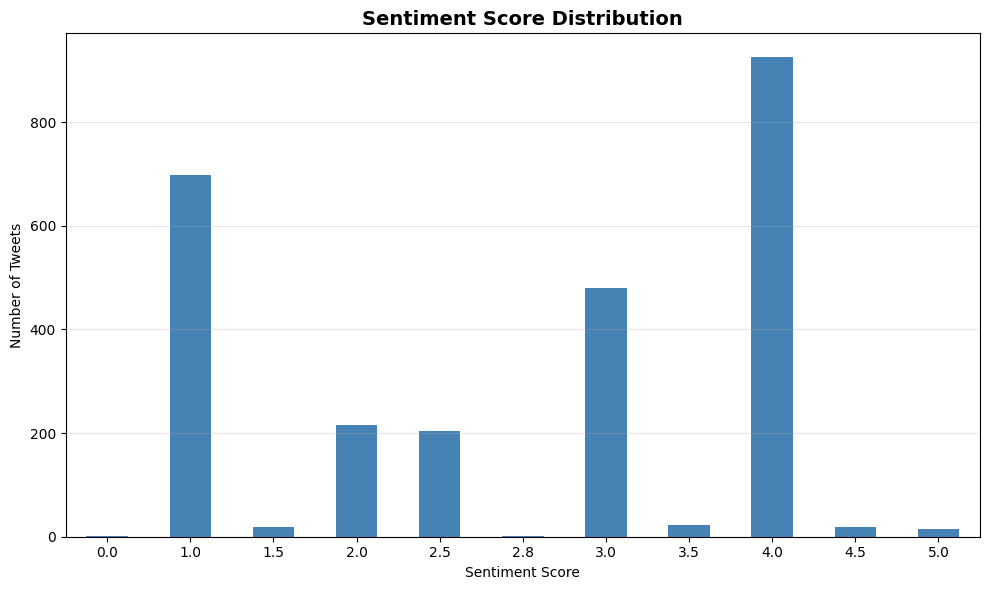


⚠️ Imbalance Ratio: 462.50x
Recommendations:
  1. Use weighted loss functions
  2. Consider oversampling minority classes
  3. Use F1-score instead of accuracy for evaluation


In [4]:
def analyze_sentiment_distribution(df):
    
    print("\n" + "="*60)
    print("SENTIMENT DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Count distribution
    sentiment_counts = df['sentiment_score'].value_counts().sort_index()
    print("\nSentiment Counts:")
    print(sentiment_counts)
    
    # Calculate class imbalance
    total = len(df)
    print("\nClass Percentages:")
    for score, count in sentiment_counts.items():
        pct = (count/total) * 100
        print(f"Score {score}: {pct:.2f}% ({count} samples)")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    sentiment_counts.plot(kind='bar', color='steelblue')
    plt.title('Sentiment Score Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment Score')
    plt.ylabel('Number of Tweets')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('sentiment_distribution.png', dpi=300)
    plt.show()
    
    # Calculate imbalance ratio (important for choosing metrics!)
    max_class = sentiment_counts.max()
    min_class = sentiment_counts.min()
    imbalance_ratio = max_class / min_class
    
    print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.2f}x")
    
    if imbalance_ratio > 3:
        print("WARNING: Significant class imbalance detected!")
        print("Recommendations:")
        print("  1. Use weighted loss functions")
        print("  2. Consider oversampling minority classes")
        print("  3. Use F1-score instead of accuracy for evaluation")
    
    return sentiment_counts

sentiment_dist = analyze_sentiment_distribution(sentiment_df)


SENTIMENT DISTRIBUTION ANALYSIS

Sentiment Counts:
sentiment_score
0.0      2
1.0    697
1.5     19
2.0    216
2.5    204
2.8      2
3.0    479
3.5     22
4.0    925
4.5     19
5.0     14
Name: count, dtype: int64

Class Percentages:
Score 0.0: 0.08% (2 samples)
Score 1.0: 26.82% (697 samples)
Score 1.5: 0.73% (19 samples)
Score 2.0: 8.31% (216 samples)
Score 2.5: 7.85% (204 samples)
Score 2.8: 0.08% (2 samples)
Score 3.0: 18.43% (479 samples)
Score 3.5: 0.85% (22 samples)
Score 4.0: 35.59% (925 samples)
Score 4.5: 0.73% (19 samples)
Score 5.0: 0.54% (14 samples)


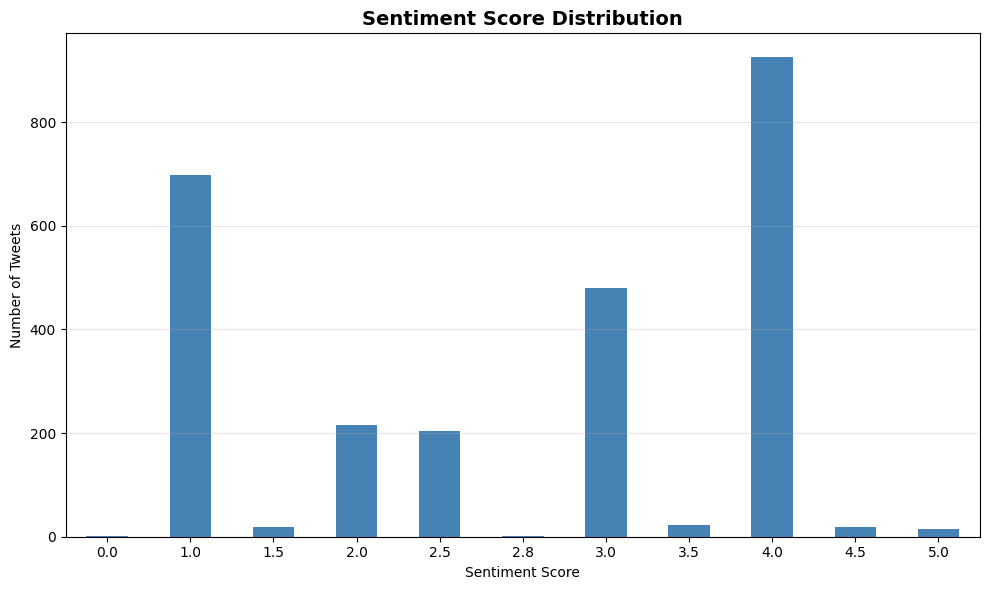


⚠️ Imbalance Ratio: 462.50x
Recommendations:
  1. Use weighted loss functions
  2. Consider oversampling minority classes
  3. Use F1-score instead of accuracy for evaluation


sentiment_score
0.0      2
1.0    697
1.5     19
2.0    216
2.5    204
2.8      2
3.0    479
3.5     22
4.0    925
4.5     19
5.0     14
Name: count, dtype: int64

In [5]:
analyze_sentiment_distribution(sentiment_df)

In [6]:
def prepare_binned_data(df):
    """
    Collapse into Negative/Neutral/Positive
    """
    print("\n" + "="*60)
    print("BINNING APPROACH (3 Classes)")
    print("="*60)
    
    # Define bins
    def categorize_sentiment(score):
        if score <= 2.0:
            return 'Negative'
        elif score <= 3.5:
            return 'Neutral'
        else:
            return 'Positive'
    
    df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)
    
    # Check distribution
    category_counts = df['sentiment_category'].value_counts()
    print("\nCategory Distribution:")
    print(category_counts)
    
    # Calculate imbalance
    total = len(df)
    for cat, count in category_counts.items():
        pct = (count/total) * 100
        print(f"{cat}: {pct:.2f}% ({count} samples)")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    category_counts.plot(kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c'])
    plt.title('Binned Sentiment Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment Category')
    plt.ylabel('Number of Tweets')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('binned_distribution.png', dpi=300)
    plt.show()
    
    # Calculate new imbalance
    max_class = category_counts.max()
    min_class = category_counts.min()
    new_imbalance = max_class / min_class
    
    print(f"\n📊 New Imbalance Ratio: {new_imbalance:.2f}x")
    
    print("\n✅ Binning Pros:")
    print("  - Easier interpretation (clear categories)")
    print("  - Reduced imbalance")
    print("  - Aligns with trading decisions (long/short/neutral)")
    
    print("\n❌ Binning Cons:")
    print("  - Loses granularity")
    print("  - Arbitrary cutoff points")
    
    return df


BINNING APPROACH (3 Classes)

Category Distribution:
sentiment_category
Positive    958
Negative    934
Neutral     707
Name: count, dtype: int64
Positive: 36.86% (958 samples)
Negative: 35.94% (934 samples)
Neutral: 27.20% (707 samples)


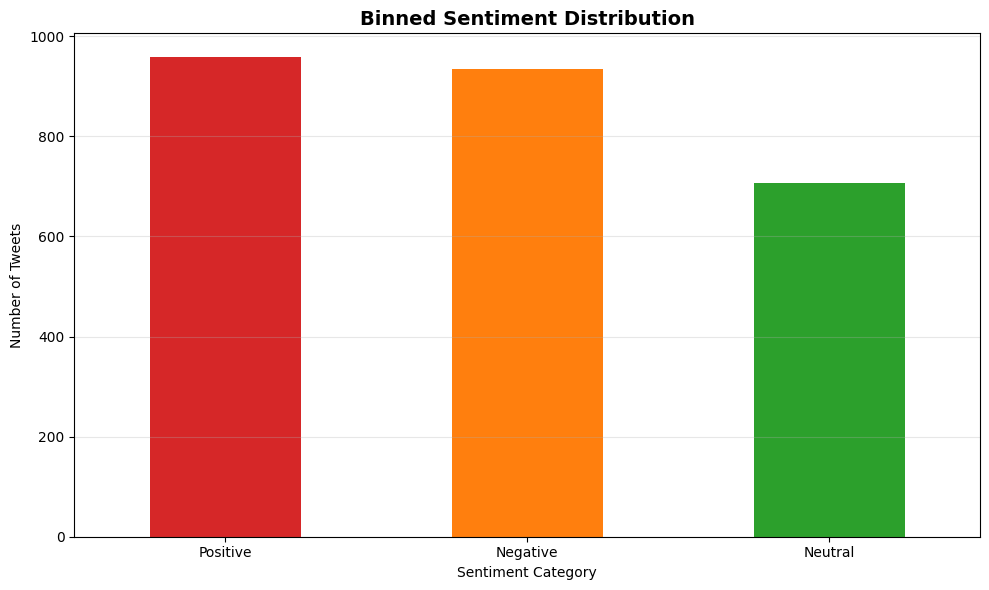


📊 New Imbalance Ratio: 1.36x

✅ Binning Pros:
  - Easier interpretation (clear categories)
  - Reduced imbalance
  - Aligns with trading decisions (long/short/neutral)

❌ Binning Cons:
  - Loses granularity
  - Arbitrary cutoff points


,new_summary,sentiment_score,sentiment_category
0,Intel has sold 214.8 million shares to NVIDIA ...,4.0,Positive
1,CITI projects a base case for the S&P 500 inde...,4.0,Positive
2,Bernstein analyst Stacy A. Rasgon maintains an...,4.0,Positive
3,"MSTR has strategically acquired 1,229 BTC and ...",4.0,Positive
4,The China Defence Ministry has called on count...,1.0,Negative
...,...,...,...
2594,Intel shares have seen a decline of 10% during...,1.0,Negative
2595,Trump is reporting record numbers on Truth Soc...,4.0,Positive
2596,"Silver has surged past $98 per ounce, reaching...",5.0,Positive
2597,Former President Trump announced that the Boar...,1.0,Negative


In [7]:
prepare_binned_data(sentiment_df)

In [8]:
 sample_tweets = [
        "$NVDA crushing earnings! Revenue up 122% YoY 🚀",
        "Fed pivoting dovish, rate cuts incoming?",
        "Horrible jobs report. Recession fears rising.",
        "$SPY ATH breakout w/ strong volume",
        "Tesla FSD Beta v11.3.2 shows improvement"
    ]

In [9]:
# ============================================================
# TOKENIZATION ANALYSIS
# ============================================================

def analyze_tokenizer(tokenizer, name, texts):
    """
    Analyze how a tokenizer handles financial tweets
    """
    print(f"\n{'='*60}")
    print(f"TOKENIZER: {name}")
    print('='*60)
    
    # Full dataset analysis
    all_token_counts = []
    special_tokens_count = 0
    unk_tokens_count = 0
    
    for text in texts:
        # Tokenize
        tokens = tokenizer.tokenize(str(text))
        all_token_counts.append(len(tokens))
        
        # Count special tokens
        special_tokens_count += sum(1 for t in tokens if t.startswith('[') or t.startswith('<'))
        unk_tokens_count += tokens.count('[UNK]') + tokens.count('<unk>')
    
    # Statistics
    print(f"\n📊 Dataset Statistics:")
    print(f"  Total tweets: {len(texts)}")
    print(f"  Avg tokens/tweet: {np.mean(all_token_counts):.2f}")
    print(f"  Max tokens: {np.max(all_token_counts)}")
    print(f"  Min tokens: {np.min(all_token_counts)}")
    print(f"  Std tokens: {np.std(all_token_counts):.2f}")
    print(f"  UNK tokens: {unk_tokens_count} ({unk_tokens_count/sum(all_token_counts)*100:.2f}%)")
    
    # Check if we need padding/truncation
    if np.max(all_token_counts) > 512:
        print(f"  ⚠️ WARNING: {sum(1 for x in all_token_counts if x > 512)} tweets exceed 512 tokens!")
    
    return {
        'name': name,
        'avg_length': np.mean(all_token_counts),
        'max_length': np.max(all_token_counts),
        'unk_count': unk_tokens_count,
        'token_counts': all_token_counts
    }





In [10]:
# ============================================================
# COMPARE POPULAR TOKENIZERS
# ============================================================

tokenizers_to_test = {
    'BERT (base-uncased)': 'bert-base-uncased',
    'RoBERTa (base)': 'roberta-base',
    'DistilBERT (base-uncased)': 'distilbert-base-uncased',
    'FinBERT (financial)': 'ProsusAI/finbert',  # Specialized for finance!
}

results = {}

for name, model_name in tokenizers_to_test.items():
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        result = analyze_tokenizer(tokenizer, name, sentiment_df['new_summary'].values)
        results[name] = result
    except Exception as e:
        print(f"Error loading {name}: {e}")




TOKENIZER: BERT (base-uncased)

📊 Dataset Statistics:
  Total tweets: 2599
  Avg tokens/tweet: 29.17
  Max tokens: 80
  Min tokens: 1
  Std tokens: 11.70
  UNK tokens: 0 (0.00%)

TOKENIZER: RoBERTa (base)

📊 Dataset Statistics:
  Total tweets: 2599
  Avg tokens/tweet: 28.15
  Max tokens: 74
  Min tokens: 1
  Std tokens: 11.13
  UNK tokens: 0 (0.00%)

TOKENIZER: DistilBERT (base-uncased)

📊 Dataset Statistics:
  Total tweets: 2599
  Avg tokens/tweet: 29.17
  Max tokens: 80
  Min tokens: 1
  Std tokens: 11.70
  UNK tokens: 0 (0.00%)

TOKENIZER: FinBERT (financial)

📊 Dataset Statistics:
  Total tweets: 2599
  Avg tokens/tweet: 29.17
  Max tokens: 80
  Min tokens: 1
  Std tokens: 11.70
  UNK tokens: 0 (0.00%)


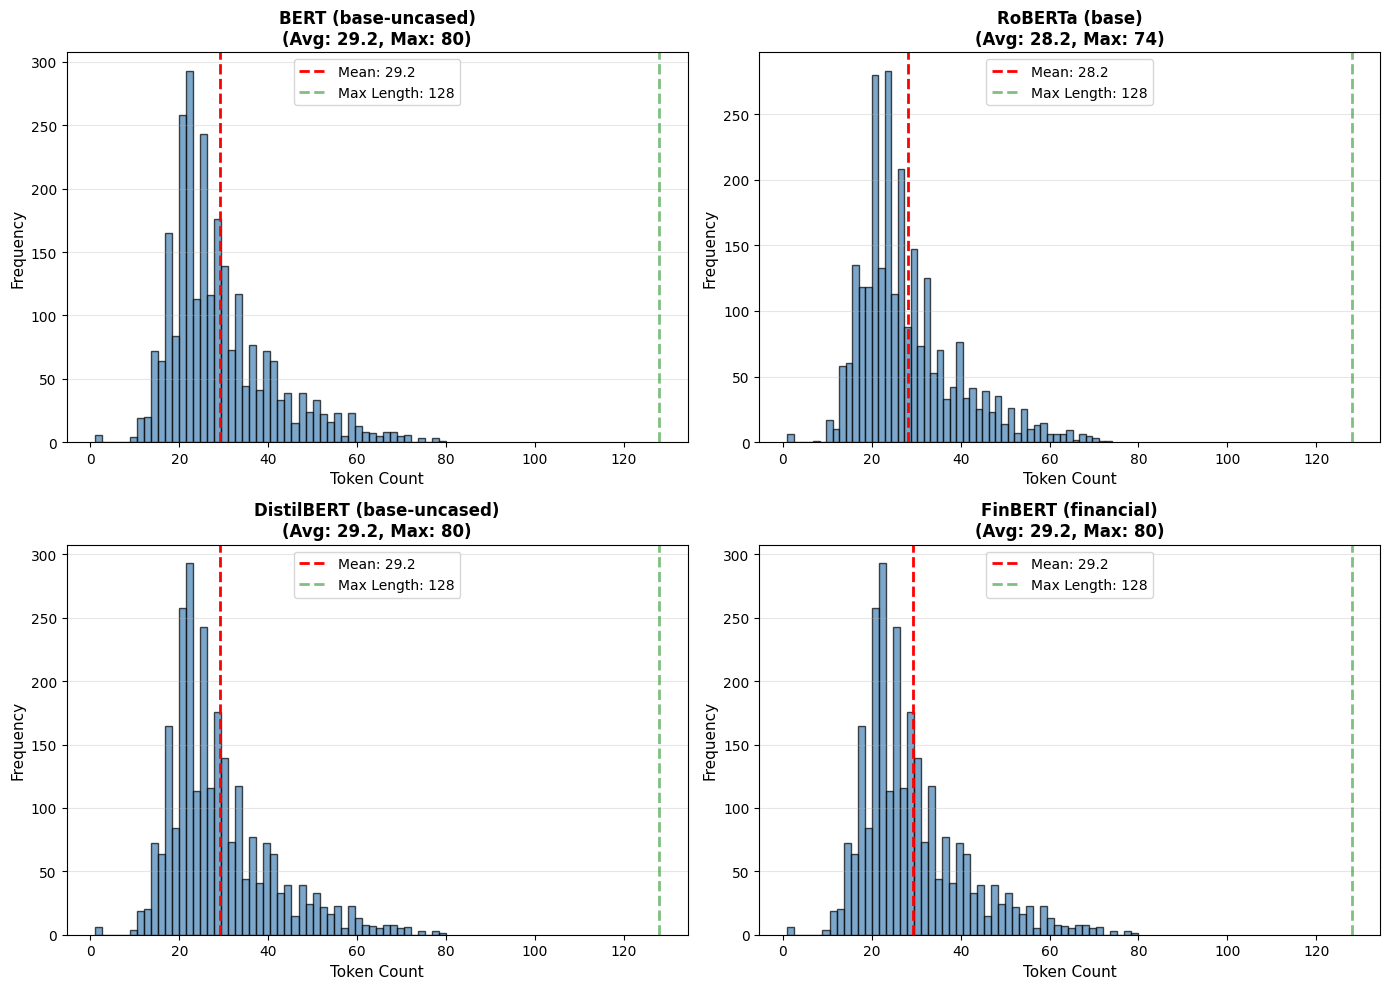

In [11]:
# ============================================================
# VISUALIZATION: TOKEN LENGTH DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Histogram
    ax.hist(result['token_counts'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(result['avg_length'], color='red', linestyle='--', linewidth=2, label=f'Mean: {result["avg_length"]:.1f}')
    ax.axvline(128, color='green', linestyle='--', linewidth=2, label='Max Length: 128', alpha=0.5)
    
    ax.set_xlabel('Token Count', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\n(Avg: {result["avg_length"]:.1f}, Max: {result["max_length"]})', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('tokenizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [12]:
# ============================================================
# FINANCIAL TEXT SPECIFIC TESTS
# ============================================================

print("\n" + "="*60)
print("FINANCIAL TEXT HANDLING TEST")
print("="*60)

financial_specific = [
    "$TSLA",           # Ticker symbol
    "YoY",             # Financial jargon
    "Q3'23",           # Quarter notation  
    "P/E",             # Ratio
    "ATH",             # All-time high
    "🚀",              # Emoji
    "10-K",            # SEC filing
    "EBITDA",          # Financial metric
]

for name, model_name in list(tokenizers_to_test.items())[:4]:  # Test 2 tokenizers
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(f"\n{name}:")
    for term in financial_specific:
        tokens = tokenizer.tokenize(term)
        print(f"  '{term}' → {tokens} ({len(tokens)} tokens)")


FINANCIAL TEXT HANDLING TEST

BERT (base-uncased):
  '$TSLA' → ['$', 'ts', '##la'] (3 tokens)
  'YoY' → ['yo', '##y'] (2 tokens)
  'Q3'23' → ['q', '##3', "'", '23'] (4 tokens)
  'P/E' → ['p', '/', 'e'] (3 tokens)
  'ATH' → ['at', '##h'] (2 tokens)
  '🚀' → ['[UNK]'] (1 tokens)
  '10-K' → ['10', '-', 'k'] (3 tokens)
  'EBITDA' → ['e', '##bit', '##da'] (3 tokens)

RoBERTa (base):
  '$TSLA' → ['$', 'TS', 'LA'] (3 tokens)
  'YoY' → ['Yo', 'Y'] (2 tokens)
  'Q3'23' → ['Q', '3', "'", '23'] (4 tokens)
  'P/E' → ['P', '/', 'E'] (3 tokens)
  'ATH' → ['ATH'] (1 tokens)
  '🚀' → ['ðŁ', 'ļ', 'Ģ'] (3 tokens)
  '10-K' → ['10', '-', 'K'] (3 tokens)
  'EBITDA' → ['E', 'BIT', 'DA'] (3 tokens)

DistilBERT (base-uncased):
  '$TSLA' → ['$', 'ts', '##la'] (3 tokens)
  'YoY' → ['yo', '##y'] (2 tokens)
  'Q3'23' → ['q', '##3', "'", '23'] (4 tokens)
  'P/E' → ['p', '/', 'e'] (3 tokens)
  'ATH' → ['at', '##h'] (2 tokens)
  '🚀' → ['[UNK]'] (1 tokens)
  '10-K' → ['10', '-', 'k'] (3 tokens)
  'EBITDA' → ['e', '##b

In [13]:
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

tweet = "$NVDA crushing Q3 earnings! Revenue up 122% YoY 🚀"

# Tokenize step by step
tokens = tokenizer.tokenize(tweet)

print("Original:", tweet)
print("\nTokens:", tokens)

Original: $NVDA crushing Q3 earnings! Revenue up 122% YoY 🚀

Tokens: ['$', 'n', '##vd', '##a', 'crushing', 'q', '##3', 'earnings', '!', 'revenue', 'up', '122', '%', 'yo', '##y', '[UNK]']


In [15]:
def set_seed(seed=42):
    """Set seeds for reproducibility across all libraries"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [16]:
# ============================================================
# MODEL CONFIGURATION
# ============================================================

class Config:
    # Model
    MODEL_NAME = 'ProsusAI/finbert'
    NUM_LABELS = 3
    MAX_LENGTH = 128
    
    # Training
    BATCH_SIZE = 16          # Adjust based on GPU memory
    LEARNING_RATE = 2e-5     # Standard for BERT fine-tuning
    NUM_EPOCHS = 10          # We'll use early stopping
    WARMUP_RATIO = 0.1       # ✅ 2025: Use ratio instead of steps
    WEIGHT_DECAY = 0.01      # L2 regularization
    
    # Advanced
    GRADIENT_ACCUMULATION_STEPS = 2  # Effective batch size = 16 * 2 = 32
    MAX_GRAD_NORM = 1.0      # Gradient clipping
    
    # Early stopping
    PATIENCE = 3             # Stop if no improvement for 3 epochs
    
    # Paths
    OUTPUT_DIR = './outputs'
    CHECKPOINT_DIR = './checkpoints'
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    USE_AMP = torch.cuda.is_available()  # Automatic Mixed Precision
    
    # DataLoader optimization
    NUM_WORKERS = 4              # Good for dual-GPU system
    PIN_MEMORY = True
    PERSISTENT_WORKERS = True
    
    # Label mapping
    LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    NUM_GPUS = 1

config = Config()

In [17]:
# Create directories
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)

# GPU Info
print("\n" + "="*80)
print("🖥️  HARDWARE CONFIGURATION - STEP 1: SINGLE GPU")
print("="*80)
print(f"Strategy: Single GPU baseline")
print(f"Device: {config.DEVICE}")

if torch.cuda.is_available():
    print(f"\nGPU 0: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  Memory Available: {torch.cuda.mem_get_info(0)[0] / 1e9:.2f} GB")
    print(f"\nGPU 1: {torch.cuda.get_device_name(1)} (unused for now)")
    print(f"  Memory: {torch.cuda.get_device_properties(1).total_memory / 1e9:.2f} GB")
    print(f"  Memory Available: {torch.cuda.mem_get_info(0)[1] / 1e9:.2f} GB")
    
    print(f"\n⚙️  Training Config:")
    print(f"  Batch Size: {config.BATCH_SIZE}")
    print(f"  Mixed Precision: {'✅ Enabled' if config.USE_AMP else '❌ Disabled'}")
    print(f"  Effective Batch: {config.BATCH_SIZE * config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"  Workers: {config.NUM_WORKERS}")


🖥️  HARDWARE CONFIGURATION - STEP 1: SINGLE GPU
Strategy: Single GPU baseline
Device: cuda

GPU 0: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.34 GB
  Memory Available: 10.55 GB

GPU 1: NVIDIA GeForce RTX 2080 Ti (unused for now)
  Memory: 11.35 GB
  Memory Available: 11.34 GB

⚙️  Training Config:
  Batch Size: 16
  Mixed Precision: ✅ Enabled
  Effective Batch: 32
  Workers: 4


In [33]:
# ============================================================
# DATASET CLASS
# ============================================================

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            #padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [34]:
# ============================================================
# DATA PREPARATION
# ============================================================

def prepare_data(df):
    
    # Reverse mapping for encoding
    LABEL_TO_ID = {v: k for k, v in config.LABEL_NAMES.items()}
    # Result: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    
    sentiment_df['label'] = sentiment_df['sentiment_category'].map(LABEL_TO_ID)

    train_df, temp_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['label']
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
    )
    
    print("\n" + "="*80)
    print("📊 DATA PREPARATION")
    print("="*80)
    print(f"Train: {len(train_df):4d} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val:   {len(val_df):4d} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test:  {len(test_df):4d} ({len(test_df)/len(df)*100:.1f}%)")
    
    return train_df, val_df, test_df

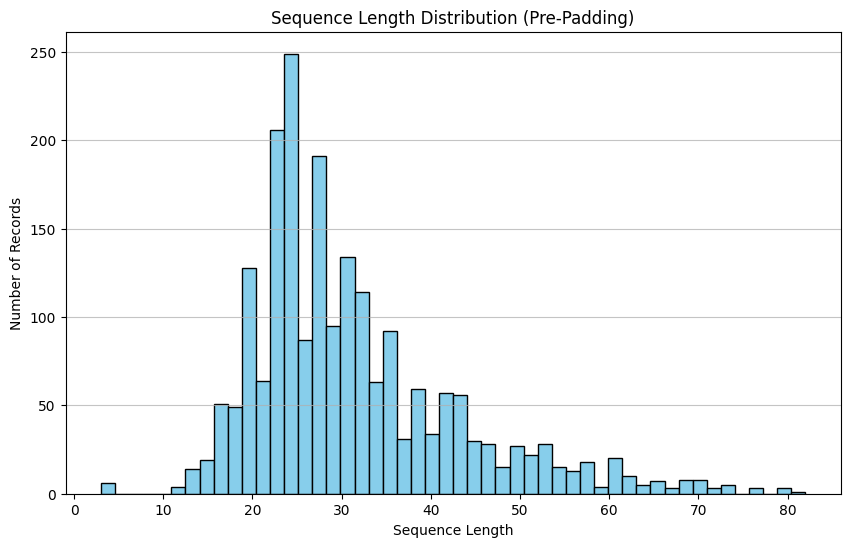

In [52]:
train_ds = SentimentDataset(train_df['new_summary'].values, train_df['label'].values, tokenizer)

lengths = [len(train_ds[i]['input_ids']) for i in range(len(train_ds))]
length_counts = Counter(lengths)

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')

plt.title("Sequence Length Distribution (Pre-Padding)")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Records")
plt.grid(axis='y', alpha=0.75)

plt.show()

In [56]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

dc = DataCollatorWithPadding(tokenizer)

train_dl = DataLoader(train_ds, batch_size=16, collate_fn=dc)

for step, batch in enumerate(train_dl):
    print(step, batch['input_ids'].shape)

0 torch.Size([16, 51])
1 torch.Size([16, 53])
2 torch.Size([16, 70])
3 torch.Size([16, 40])
4 torch.Size([16, 53])
5 torch.Size([16, 54])
6 torch.Size([16, 70])
7 torch.Size([16, 61])
8 torch.Size([16, 69])
9 torch.Size([16, 62])
10 torch.Size([16, 49])
11 torch.Size([16, 82])
12 torch.Size([16, 62])
13 torch.Size([16, 74])
14 torch.Size([16, 65])
15 torch.Size([16, 56])
16 torch.Size([16, 56])
17 torch.Size([16, 61])
18 torch.Size([16, 64])
19 torch.Size([16, 71])
20 torch.Size([16, 49])
21 torch.Size([16, 56])
22 torch.Size([16, 54])
23 torch.Size([16, 50])
24 torch.Size([16, 77])
25 torch.Size([16, 47])
26 torch.Size([16, 49])
27 torch.Size([16, 40])
28 torch.Size([16, 68])
29 torch.Size([16, 58])
30 torch.Size([16, 34])
31 torch.Size([16, 61])
32 torch.Size([16, 58])
33 torch.Size([16, 69])
34 torch.Size([16, 60])
35 torch.Size([16, 56])
36 torch.Size([16, 58])
37 torch.Size([16, 50])
38 torch.Size([16, 43])
39 torch.Size([16, 41])
40 torch.Size([16, 44])
41 torch.Size([16, 48])
42

In [95]:
sampler = LengthBasedBatchSampler(
        lengths=lengths,
        batch_size=16,
        drop_last=False 
    )
train_dl = DataLoader(train_ds, collate_fn=dc, batch_sampler=sampler)
for step, batch in enumerate(train_dl):
    print(step, batch['input_ids'].shape)

0 torch.Size([16, 27])
1 torch.Size([16, 19])
2 torch.Size([16, 39])
3 torch.Size([16, 23])
4 torch.Size([16, 39])
5 torch.Size([16, 23])
6 torch.Size([16, 30])
7 torch.Size([16, 47])
8 torch.Size([16, 21])
9 torch.Size([16, 79])
10 torch.Size([16, 27])
11 torch.Size([16, 30])
12 torch.Size([16, 21])
13 torch.Size([16, 19])
14 torch.Size([16, 25])
15 torch.Size([16, 74])
16 torch.Size([16, 19])
17 torch.Size([9, 19])
18 torch.Size([16, 21])
19 torch.Size([16, 25])
20 torch.Size([16, 47])
21 torch.Size([16, 19])
22 torch.Size([16, 25])
23 torch.Size([16, 77])
24 torch.Size([16, 25])
25 torch.Size([16, 70])
26 torch.Size([16, 39])
27 torch.Size([5, 36])
28 torch.Size([16, 30])
29 torch.Size([16, 23])
30 torch.Size([16, 21])
31 torch.Size([16, 33])
32 torch.Size([16, 39])
33 torch.Size([16, 73])
34 torch.Size([16, 39])
35 torch.Size([16, 39])
36 torch.Size([16, 68])
37 torch.Size([13, 45])
38 torch.Size([16, 25])
39 torch.Size([16, 23])
40 torch.Size([16, 25])
41 torch.Size([16, 25])
42 t

In [90]:
from torch.utils.data import DataLoader, Sampler
import numpy as np
from typing import List, Iterator

class LengthBasedBatchSampler(Sampler):
    """
    Groups samples into batches by similar sequence length.
    Reduces padding overhead by up to 40-60% compared to random batching.
    """
    
    def __init__(
        self, 
        lengths: List[int], 
        batch_size: int, 
        drop_last: bool = False,
        bucket_boundaries: List[int] = None
    ):
        self.lengths = np.array(lengths)
        self.batch_size = batch_size
        self.drop_last = drop_last
        
        # Auto-create buckets if not provided
        if bucket_boundaries is None:
            bucket_boundaries = self._create_buckets()
        self.bucket_boundaries = bucket_boundaries
        
        # Assign samples to buckets
        self.buckets = self._assign_to_buckets()
        
    def _create_buckets(self, n_buckets: int = 10) -> List[int]:
        """Create bucket boundaries using percentiles"""
        percentiles = np.linspace(0, 100, n_buckets + 1)
        boundaries = np.percentile(self.lengths, percentiles).astype(int)
        return sorted(set(boundaries))  # Remove duplicates
    
    def _assign_to_buckets(self) -> List[List[int]]:
        """Assign each sample index to appropriate bucket"""
        buckets = [[] for _ in range(len(self.bucket_boundaries) - 1)]
        
        for idx, length in enumerate(self.lengths):
            # Find appropriate bucket
            for i in range(len(self.bucket_boundaries) - 1):
                if self.bucket_boundaries[i] <= length < self.bucket_boundaries[i + 1]:
                    buckets[i].append(idx)
                    break
        
        # Shuffle within each bucket
        for bucket in buckets:
            np.random.shuffle(bucket)
            
        return buckets
    
    def __iter__(self) -> Iterator[List[int]]:
        # Create batches from each bucket
        all_batches = []
        
        for bucket in self.buckets:
            # Skip empty buckets
            if len(bucket) == 0:
                continue
                
            # Create batches from this bucket
            for i in range(0, len(bucket), self.batch_size):
                batch = bucket[i:i + self.batch_size]
                
                if len(batch) == self.batch_size or not self.drop_last:
                    all_batches.append(batch)
        
        # Shuffle batches (not samples within batches)
        np.random.shuffle(all_batches)
        
        for batch in all_batches:
            yield batch
    
    def __len__(self) -> int:
        total_batches = sum(
            len(bucket) // self.batch_size + (0 if self.drop_last else (len(bucket) % self.batch_size > 0))
            for bucket in self.buckets
        )
        return total_batches


In [89]:
def _create_buckets(n_buckets: int = 10):
    # Calculate percentiles
    percentiles = np.linspace(0, 100, n_buckets + 1)
    # [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    
    boundaries = np.percentile(lengths, percentiles).astype(int)
    buckets = [[] for _ in range(len(boundaries) - 1)]
    print(buckets)
    for idx, length in enumerate(lengths):
        # Find which bucket this length belongs to
        for i in range(len(boundaries) - 1):
            if boundaries[i] <= length < boundaries[i + 1]:
                buckets[i].append(idx)
                break
                
    print(buckets)
                
    return sorted(set(boundaries))


_create_buckets()

[[], [], [], [], [], [], [], [], [], []]
[[1, 2, 6, 14, 16, 43, 44, 48, 49, 52, 61, 63, 76, 78, 100, 101, 102, 108, 114, 121, 131, 165, 168, 181, 198, 200, 213, 236, 240, 249, 254, 288, 303, 319, 324, 333, 342, 348, 359, 361, 379, 388, 391, 425, 428, 431, 437, 444, 457, 461, 462, 503, 512, 530, 552, 558, 559, 566, 572, 590, 592, 594, 608, 610, 627, 628, 633, 672, 686, 699, 701, 702, 704, 714, 723, 729, 742, 749, 755, 765, 775, 780, 782, 784, 788, 791, 811, 829, 850, 856, 858, 863, 866, 867, 868, 870, 875, 876, 880, 890, 892, 900, 904, 910, 917, 939, 942, 953, 957, 961, 967, 981, 984, 1003, 1014, 1033, 1072, 1077, 1085, 1096, 1108, 1110, 1118, 1120, 1133, 1175, 1178, 1188, 1191, 1210, 1238, 1242, 1253, 1259, 1267, 1274, 1285, 1292, 1301, 1305, 1308, 1324, 1334, 1336, 1343, 1350, 1376, 1381, 1386, 1411, 1418, 1422, 1424, 1434, 1435, 1511, 1534, 1552, 1554, 1558, 1577, 1588, 1603, 1608, 1611, 1660, 1691, 1693, 1700, 1714, 1715, 1716, 1735, 1744, 1767, 1789, 1790, 1817, 1845, 1850, 1879, 1

[np.int64(3),
 np.int64(20),
 np.int64(22),
 np.int64(24),
 np.int64(26),
 np.int64(28),
 np.int64(31),
 np.int64(34),
 np.int64(40),
 np.int64(48),
 np.int64(82)]

In [20]:
train_df, val_df, test_df = prepare_data(sentiment_df)


📊 DATA PREPARATION
Train: 2079 (80.0%)
Val:    260 (10.0%)
Test:   260 (10.0%)


In [74]:
def calculate_class_weights(labels):
    from sklearn.utils.class_weight import compute_class_weight
    
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(labels),
        y=labels
    )
    
    print("\n" + "="*80)
    print("⚖️  CLASS WEIGHTS")
    print("="*80)
    for idx, weight in enumerate(class_weights):
        print(f"  {config.LABEL_NAMES[idx]:<10}: {weight:.4f}")
    
    return torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)


lass_weights = calculate_class_weights(train_df['label'].values)


⚖️  CLASS WEIGHTS
  Negative  : 0.9277
  Neutral   : 1.2244
  Positive  : 0.9047


In [75]:
# TRAINING FUNCTION
# ============================================================

def train_epoch(model, data_loader, optimizer, scheduler, class_weights, epoch, scaler=None):
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    progress_bar = tqdm(
        data_loader, 
        desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS} [Train]',
        leave=True
    )
    
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(config.DEVICE)
        attention_mask = batch['attention_mask'].to(config.DEVICE)
        labels = batch['labels'].to(config.DEVICE)
        
        if config.USE_AMP and scaler is not None:
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = criterion(logits, labels)
            
            loss = loss / config.GRADIENT_ACCUMULATION_STEPS
            scaler.scale(loss).backward()
            
            if (step + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)
            
            loss = loss / config.GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            
            if (step + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
        
        total_loss += loss.item() * config.GRADIENT_ACCUMULATION_STEPS
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({
            'loss': f'{total_loss/(step+1):.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average='macro')
    
    return avg_loss, accuracy, macro_f1

In [76]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate(model, data_loader, class_weights):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    progress_bar = tqdm(data_loader, desc='Evaluating', leave=False)
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(config.DEVICE)
        attention_mask = batch['attention_mask'].to(config.DEVICE)
        labels = batch['labels'].to(config.DEVICE)
        
        if config.USE_AMP:
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = criterion(logits, labels)
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average='macro')
    
    report = classification_report(
        true_labels, 
        predictions,
        target_names=[config.LABEL_NAMES[i] for i in range(config.NUM_LABELS)],
        digits=4
    )
    
    return avg_loss, accuracy, macro_f1, predictions, true_labels, report

In [77]:
sentiment_df

,new_summary,sentiment_score,sentiment_category,label
0,Intel has sold 214.8 million shares to NVIDIA ...,4.0,Positive,2
1,CITI projects a base case for the S&P 500 inde...,4.0,Positive,2
2,Bernstein analyst Stacy A. Rasgon maintains an...,4.0,Positive,2
3,"MSTR has strategically acquired 1,229 BTC and ...",4.0,Positive,2
4,The China Defence Ministry has called on count...,1.0,Negative,0
...,...,...,...,...
2594,Intel shares have seen a decline of 10% during...,1.0,Negative,0
2595,Trump is reporting record numbers on Truth Soc...,4.0,Positive,2
2596,"Silver has surged past $98 per ounce, reaching...",5.0,Positive,2
2597,Former President Trump announced that the Boar...,1.0,Negative,0


In [114]:
# ============================================================
# MAIN TRAINING LOOP
# ============================================================

def train_model(tokenizer):
    print("\n" + "="*80)
    print("🚀 STEP 1: SINGLE GPU BASELINE TRAINING")
    print("="*80)
    print(f"📅 Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Prepare data
    train_df, val_df, test_df = prepare_data(sentiment_df)
    dc = DataCollatorWithPadding(tokenizer=tokenizer, padding=True,
        max_length=None)
    
    sampler = LengthBasedBatchSampler(
        lengths=lengths,
        batch_size=16,
        drop_last=False 
    )

    # Initialize tokenizer and model
    print("\n" + "="*80)
    print("🤖 LOADING MODEL")
    print("="*80)
    tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS,
        ignore_mismatched_sizes=True
    )
    model.to(config.DEVICE)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"✅ Model loaded: {config.MODEL_NAME}")
    print(f"   Total Parameters: {total_params:,}")
    print(f"   Trainable Parameters: {trainable_params:,}")
    print(f"   Model Size: ~{total_params * 4 / 1e6:.0f} MB (float32)")
    
    # Create datasets
    train_dataset = SentimentDataset(
        train_df['new_summary'].values, train_df['label'].values, 
        tokenizer, config.MAX_LENGTH
    )
    val_dataset = SentimentDataset(
        val_df['new_summary'].values, val_df['label'].values,
        tokenizer, config.MAX_LENGTH
    )
    test_dataset = SentimentDataset(
        test_df['new_summary'].values, test_df['label'].values,
        tokenizer, config.MAX_LENGTH
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        #batch_size=config.BATCH_SIZE, 
        #shuffle=True,
        #num_workers=config.NUM_WORKERS,
        num_workers=0,
        pin_memory=config.PIN_MEMORY,
        #persistent_workers=config.PERSISTENT_WORKERS,
        collate_fn=dc,
        batch_sampler=sampler
    )
    val_loader = DataLoader(
        val_dataset, 
        #batch_size=config.BATCH_SIZE, 
        #shuffle=False,
        #num_workers=config.NUM_WORKERS,
        num_workers=0,
        pin_memory=config.PIN_MEMORY,
        #persistent_workers=config.PERSISTENT_WORKERS,
        collate_fn=dc,
        batch_sampler=sampler
    )
    test_loader = DataLoader(
        test_dataset, 
        #batch_size=config.BATCH_SIZE, 
        #shuffle=False,
        #num_workers=config.NUM_WORKERS,
        num_workers=0,
        pin_memory=config.PIN_MEMORY,
        collate_fn=dc,
        batch_sampler=sampler
    )
    
    # Calculate class weights
    class_weights = calculate_class_weights(train_df['label'].values)
    
    # Optimizer
    print("\n" + "="*80)
    print("⚙️  OPTIMIZER SETUP")
    print("="*80)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        eps=1e-8,
        betas=(0.9, 0.999),
        fused=True
    )
    print(f"✅ PyTorch native AdamW (fused=True)")
    
    # Scheduler
    total_steps = len(train_loader) * config.NUM_EPOCHS // config.GRADIENT_ACCUMULATION_STEPS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    
    warmup_scheduler = LinearLR(
        optimizer, 
        start_factor=0.01,
        end_factor=1.0,
        total_iters=warmup_steps
    )
    
    decay_scheduler = LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.0,
        total_iters=total_steps - warmup_steps
    )
    
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, decay_scheduler],
        milestones=[warmup_steps]
    )
    
    print(f"   Learning Rate: {config.LEARNING_RATE}")
    print(f"   Warmup Steps: {warmup_steps} ({config.WARMUP_RATIO*100:.0f}%)")
    print(f"   Total Steps: {total_steps}")
    print(f"   Batches per Epoch: {len(train_loader)}")
    
    # GradScaler for mixed precision
    scaler = torch.amp.GradScaler('cuda') if config.USE_AMP else None
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'learning_rates': []
    }
    
    # Early stopping
    best_val_f1 = 0
    patience_counter = 0
    
    print("\n" + "="*80)
    print("🏋️  TRAINING START")
    print("="*80)
    
    # Training loop
    start_time = datetime.now()
    
    for epoch in range(config.NUM_EPOCHS):
        epoch_start = datetime.now()
        
        # Train
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, optimizer, scheduler, class_weights, epoch, scaler
        )
        
        # Validate
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, class_weights)
        
        epoch_time = (datetime.now() - epoch_start).total_seconds()
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['learning_rates'].append(scheduler.get_last_lr()[0])
        
        # Print epoch summary
        print(f"\n{'='*80}")
        print(f"📊 Epoch {epoch+1}/{config.NUM_EPOCHS} Summary (Time: {epoch_time:.1f}s)")
        print('='*80)
        print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Δ':<10}")
        print('-'*50)
        print(f"{'Loss':<15} {train_loss:<12.4f} {val_loss:<12.4f} {val_loss-train_loss:+.4f}")
        print(f"{'Accuracy':<15} {train_acc:<12.4f} {val_acc:<12.4f} {val_acc-train_acc:+.4f}")
        print(f"{'Macro-F1':<15} {train_f1:<12.4f} {val_f1:<12.4f} {val_f1-train_f1:+.4f}")
        
        # Early stopping check
        if val_f1 > best_val_f1:
            improvement = val_f1 - best_val_f1
            best_val_f1 = val_f1
            patience_counter = 0
            
            checkpoint_path = os.path.join(config.CHECKPOINT_DIR, 'best_model_single_gpu.pt')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_f1': val_f1,
                'history': history,
                'config': {
                    'batch_size': config.BATCH_SIZE,
                    'learning_rate': config.LEARNING_RATE,
                    'num_gpus': config.NUM_GPUS
                }
            }, checkpoint_path)
            print(f"\n✅ New best model saved! (Val F1: {val_f1:.4f}, +{improvement:.4f})")
        else:
            patience_counter += 1
            print(f"\n⏳ No improvement for {patience_counter} epoch(s) (patience: {config.PATIENCE})")
            
            if patience_counter >= config.PATIENCE:
                print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
                print(f"   Best Val F1: {best_val_f1:.4f} (Epoch {epoch+1-patience_counter})")
                break
    
    total_time = (datetime.now() - start_time).total_seconds()
    
    # Load best model
    print("\n" + "="*80)
    print("📂 LOADING BEST MODEL")
    print("="*80)
    checkpoint = torch.load(os.path.join(config.CHECKPOINT_DIR, 'best_model_single_gpu.pt'))
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
    
    # Final test evaluation
    print("\n" + "="*80)
    print("🎯 FINAL TEST EVALUATION")
    print("="*80)
    
    test_loss, test_acc, test_f1, test_preds, test_labels, test_report = evaluate(
        model, test_loader, class_weights
    )
    
    print(f"\n{'Metric':<20} {'Score':<10}")
    print('-'*30)
    print(f"{'Test Loss':<20} {test_loss:.4f}")
    print(f"{'Test Accuracy':<20} {test_acc:.4f}")
    print(f"{'Test Macro-F1':<20} {test_f1:.4f}")
    print(f"\n{'='*80}")
    print("📋 DETAILED CLASSIFICATION REPORT")
    print('='*80)
    print(test_report)
    
    # Plot confusion matrix
    plot_confusion_matrix(test_labels, test_preds)
    
    # Plot training history
    plot_training_history(history)
    
    # Save final artifacts
    print("\n" + "="*80)
    print("💾 SAVING ARTIFACTS")
    print("="*80)
    
    model.save_pretrained(os.path.join(config.OUTPUT_DIR, 'final_model_single_gpu'))
    tokenizer.save_pretrained(os.path.join(config.OUTPUT_DIR, 'final_model_single_gpu'))
    
    results = {
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'test_macro_f1': float(test_f1),
        'best_val_f1': float(best_val_f1),
        'total_training_time_seconds': float(total_time),
        'config': {
            'model': config.MODEL_NAME,
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'num_epochs': config.NUM_EPOCHS,
            'max_length': config.MAX_LENGTH,
            'num_gpus': config.NUM_GPUS,
            'use_amp': config.USE_AMP
        }
    }
    
    with open(os.path.join(config.OUTPUT_DIR, 'training_history_single_gpu.json'), 'w') as f:
        json.dump(history, f, indent=2)
    
    with open(os.path.join(config.OUTPUT_DIR, 'test_results_single_gpu.json'), 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"✅ Model: {config.OUTPUT_DIR}/final_model_single_gpu")
    print(f"✅ History: {config.OUTPUT_DIR}/training_history_single_gpu.json")
    print(f"✅ Results: {config.OUTPUT_DIR}/test_results_single_gpu.json")
    
    print(f"\n{'='*80}")
    print(f"✨ STEP 1 COMPLETE - SINGLE GPU BASELINE")
    print(f"{'='*80}")
    print(f"📅 Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"⏱️  Total Time: {total_time/60:.1f} minutes")
    print(f"🎯 Test F1: {test_f1:.4f}")
    
    print(f"\n{'='*80}")
    print(f"📈 NEXT STEP: Multi-GPU Training")
    print(f"{'='*80}")
    print(f"Expected improvements with 2 GPUs:")
    print(f"  - Training Speed: ~1.8-2.0x faster")
    print(f"  - Effective Batch: {config.BATCH_SIZE * 2} (double)")
    print(f"  - Time per Epoch: ~{epoch_time/2:.1f}s (estimated)")
    
    return model, tokenizer, history, results



In [115]:
# ============================================================
# VISUALIZATION FUNCTIONS
# ============================================================

def plot_confusion_matrix(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
    
    sns.heatmap(
        cm, annot=annotations, fmt='', cmap='Blues',
        xticklabels=[config.LABEL_NAMES[i] for i in range(config.NUM_LABELS)],
        yticklabels=[config.LABEL_NAMES[i] for i in range(config.NUM_LABELS)],
        cbar_kws={'label': 'Count'},
        ax=ax
    )
    
    ax.set_title('Confusion Matrix - Test Set (Single GPU)', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'confusion_matrix_single_gpu.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("📊 PER-CLASS ACCURACY")
    print("="*80)
    for i in range(config.NUM_LABELS):
        class_acc = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        class_total = cm[i, :].sum()
        class_correct = cm[i, i]
        print(f"{config.LABEL_NAMES[i]:<12}: {class_acc:6.2%} ({class_correct}/{class_total} correct)")


def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=6)
    ax.plot(epochs, history['val_loss'], 'r-s', label='Validation', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Loss vs Epoch (Single GPU)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Accuracy
    ax = axes[0, 1]
    ax.plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=6)
    ax.plot(epochs, history['val_acc'], 'r-s', label='Validation', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Accuracy vs Epoch (Single GPU)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # F1 Score
    ax = axes[1, 0]
    ax.plot(epochs, history['train_f1'], 'b-o', label='Train', linewidth=2, markersize=6)
    ax.plot(epochs, history['val_f1'], 'r-s', label='Validation', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Macro-F1', fontsize=11)
    ax.set_title('Macro-F1 vs Epoch (Single GPU)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Learning Rate
    ax = axes[1, 1]
    ax.plot(epochs, history['learning_rates'], 'g-^', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Learning Rate', fontsize=11)
    ax.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'training_curves_single_gpu.png'), dpi=300, bbox_inches='tight')
    plt.show()

In [116]:
model, tokenizer, history, results = train_model(tokenizer)


🚀 STEP 1: SINGLE GPU BASELINE TRAINING
📅 Started: 2026-01-29 15:56:50

📊 DATA PREPARATION
Train: 2079 (80.0%)
Val:    260 (10.0%)
Test:   260 (10.0%)

🤖 LOADING MODEL
✅ Model loaded: ProsusAI/finbert
   Total Parameters: 109,484,547
   Trainable Parameters: 109,484,547
   Model Size: ~438 MB (float32)

⚖️  CLASS WEIGHTS
  Negative  : 0.9277
  Neutral   : 1.2244
  Positive  : 0.9047

⚙️  OPTIMIZER SETUP
✅ PyTorch native AdamW (fused=True)
   Learning Rate: 2e-05
   Warmup Steps: 67 (10%)
   Total Steps: 675
   Batches per Epoch: 135

🏋️  TRAINING START


Epoch 1/10 [Train]: 100%|███████████████████████████████████| 135/135 [00:04<00:00, 32.43it/s, loss=1.5066, lr=2.00e-05]


IndexError: index 1937 is out of bounds for axis 0 with size 260

In [61]:
# ============================================================
# CONVERT TO HUGGINGFACE DATASETS
# ============================================================

def create_hf_dataset(df, tokenizer, max_length=128):
    """
    Convert pandas DataFrame to HuggingFace Dataset
    
    ✅ HuggingFace handles tokenization automatically!
    """
    df['label'] = df['label'].astype(int)
    
    # ✅ FIX 2: Clean tweet column
    # Remove NaN, None, and convert all to strings
    df['new_summary'] = df['new_summary'].fillna('')  # Replace NaN with empty string
    df['new_summary'] = df['new_summary'].astype(str)  # Force to string
    
    # ✅ FIX 3: Remove empty tweets
    df = df[df['new_summary'].str.strip() != '']
    
    # Create HuggingFace Dataset from pandas
    dataset = hf_dataset.from_pandas(df[['new_summary', 'label']])
    
    print(dataset)
    
    # Tokenize function
    def tokenize_function(examples):
        return tokenizer(
            examples['new_summary'],
            padding='max_length',
            truncation=True,
            max_length=max_length
        )
    
    # Apply tokenization (batched for speed)
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=['new_summary']# Remove raw text, keep only tokens
    )
    
    # Set format for PyTorch
    tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    
    return tokenized_dataset


In [62]:
# ============================================================
# COMPUTE METRICS (for evaluation during training)
# ============================================================

def compute_metrics(eval_pred):
    """
    Compute metrics during training
    Called automatically by Trainer
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }


# ============================================================
# CUSTOM CALLBACK FOR CLASS WEIGHTS
# ============================================================

class WeightedLossTrainer(Trainer):
    """
    Custom Trainer with class weights
    ✅ Updated for Transformers 4.x (2025)
    """
    
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        ✅ FIXED: Added num_items_in_batch parameter for new Trainer API
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Weighted cross-entropy loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss


In [82]:
# ============================================================
# MAIN TRAINING FUNCTION
# ============================================================

def train_with_huggingface(tokenizer):
    """
    Complete training pipeline using HuggingFace Trainer
    
    ✅ 2025 Best Practice
    """
    
    print("\n" + "="*80)
    print("🚀 HUGGINGFACE TRAINER - PRODUCTION APPROACH")
    print("="*80)
    
    # Configuration
    MODEL_NAME = 'ProsusAI/finbert'
    MAX_LENGTH = 128
    OUTPUT_DIR = './outputs_hf'
    
    # Prepare data
    #train_df, val_df, test_df = prepare_data(sentiment_df)
    
    # Load tokenizer and model
    print("\n" + "="*80)
    print("🤖 LOADING MODEL")
    print("="*80)
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        ignore_mismatched_sizes=True
    )
    
    dc = DataCollatorWithPadding(tokenizer)
    print(f"✅ Model: {MODEL_NAME}")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Create HuggingFace datasets
    print("\n" + "="*80)
    print("📦 CREATING DATASETS")
    print("="*80)
    
    train_dataset = create_hf_dataset(train_df, tokenizer, MAX_LENGTH)
    val_dataset = create_hf_dataset(val_df, tokenizer, MAX_LENGTH)
    test_dataset = create_hf_dataset(test_df, tokenizer, MAX_LENGTH)
    
    print(f"✅ Datasets created and tokenized")
    
    # Calculate class weights
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_df['label']),
        y=train_df['label'].values
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32)
    
    if torch.cuda.is_available():
        class_weights = class_weights.cuda()
    
    print("\n" + "="*80)
    print("⚖️  CLASS WEIGHTS")
    print("="*80)
    for idx, weight in enumerate(class_weights):
        print(f"  Class {idx}: {weight:.4f}")
    
    # ✅ TRAINING ARGUMENTS - ALL CONFIG IN ONE PLACE
    print("\n" + "="*80)
    print("⚙️  TRAINING CONFIGURATION")
    print("="*80)
    
    training_args = TrainingArguments(
        # Output
        output_dir=OUTPUT_DIR,
        overwrite_output_dir=True,
        
        # Training hyperparameters
        num_train_epochs=10,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        
        # Optimization
        gradient_accumulation_steps=1,
        max_grad_norm=1.0,
        fp16=torch.cuda.is_available(),  # Mixed precision
        
        # Evaluation & Saving
        eval_strategy='epoch',  # Evaluate after each epoch
        save_strategy='epoch',
        save_total_limit=2,  # Keep only 2 best checkpoints
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        
        # Logging
        logging_dir=f'{OUTPUT_DIR}/logs',
        logging_strategy='steps',
        logging_steps=50,
        report_to='none',  # Can add 'wandb' for Weights & Biases
        
        # Performance
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        
        # Reproducibility
        seed=42,
        data_seed=42,
            )
    
    print(f"✅ Configuration set")
    print(f"   Batch Size: {training_args.per_device_train_batch_size}")
    print(f"   Learning Rate: {training_args.learning_rate}")
    print(f"   Mixed Precision: {training_args.fp16}")
    print(f"   Eval Strategy: {training_args.eval_strategy}")
    
    # ✅ CREATE TRAINER
    print("\n" + "="*80)
    print("🏋️  INITIALIZING TRAINER")
    print("="*80)
    
    trainer = WeightedLossTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=3,
                early_stopping_threshold=0.0
            )
        ],
        data_collator=dc
    )
    
    print("✅ Trainer initialized")
    
    # ✅ TRAIN - ONE LINE!
    print("\n" + "="*80)
    print("🚀 TRAINING START")
    print("="*80)
    
    train_result = trainer.train()
    
    print("\n" + "="*80)
    print("✅ TRAINING COMPLETE")
    print("="*80)
    print(f"   Best model saved to: {OUTPUT_DIR}")
    
    # ✅ EVALUATE ON TEST SET
    print("\n" + "="*80)
    print("🎯 FINAL TEST EVALUATION")
    print("="*80)
    
    test_results = trainer.evaluate(test_dataset)
    
    print(f"\n{'Metric':<20} {'Score':<10}")
    print('-'*30)
    for metric, value in test_results.items():
        if not metric.startswith('eval_'):
            continue
        metric_name = metric.replace('eval_', '').replace('_', ' ').title()
        print(f"{metric_name:<20} {value:.4f}")
    
    # ✅ DETAILED PREDICTIONS
    predictions = trainer.predict(test_dataset)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids
    
    report = classification_report(
        true_labels,
        pred_labels,
        target_names=['Negative', 'Neutral', 'Positive'],
        digits=4
    )
    
    print("\n" + "="*80)
    print("📋 DETAILED CLASSIFICATION REPORT")
    print("="*80)
    print(report)
    
    # ✅ SAVE FINAL MODEL
    trainer.save_model(f'{OUTPUT_DIR}/final_model')
    tokenizer.save_pretrained(f'{OUTPUT_DIR}/final_model')
    
    # Save results
    results_dict = {
        'test_metrics': test_results,
        'training_time': train_result.metrics.get('train_runtime', 0),
        'best_epoch': trainer.state.best_model_checkpoint,
        'config': {
            'model': MODEL_NAME,
            'batch_size': training_args.per_device_train_batch_size,
            'learning_rate': training_args.learning_rate,
            'epochs': training_args.num_train_epochs,
        }
    }
    
    with open(f'{OUTPUT_DIR}/results.json', 'w') as f:
        json.dump(results_dict, f, indent=2)
    
    print(f"\n✅ Results saved to: {OUTPUT_DIR}/results.json")
    
    return trainer, test_results


In [83]:
trainer, results = train_with_huggingface(tokenizer)


🚀 HUGGINGFACE TRAINER - PRODUCTION APPROACH

🤖 LOADING MODEL
✅ Model: ProsusAI/finbert
   Parameters: 109,484,547

📦 CREATING DATASETS
Dataset({
    features: ['new_summary', 'label', '__index_level_0__'],
    num_rows: 2073
})


Map:   0%|          | 0/2073 [00:00<?, ? examples/s]

Dataset({
    features: ['new_summary', 'label', '__index_level_0__'],
    num_rows: 260
})


Map:   0%|          | 0/260 [00:00<?, ? examples/s]

Dataset({
    features: ['new_summary', 'label', '__index_level_0__'],
    num_rows: 260
})


...

✅ Datasets created and tokenized

⚖️  CLASS WEIGHTS
  Class 0: 0.9277
  Class 1: 1.2244
  Class 2: 0.9047

⚙️  TRAINING CONFIGURATION
✅ Configuration set
   Batch Size: 32
   Learning Rate: 2e-05
   Mixed Precision: True
   Eval Strategy: IntervalStrategy.EPOCH

🏋️  INITIALIZING TRAINER
✅ Trainer initialized

🚀 TRAINING START


/tmp/ipykernel_6602/512701759.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
/home/rchiluka/miniconda3/envs/tradingbot/lib/python3.11/site-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,No log,1.018595,0.438462,0.384796,0.378959
2,1.431100,0.728781,0.734615,0.720218,0.729850
3,1.431100,0.607717,0.776923,0.765167,0.774657
4,0.670700,0.584527,0.792308,0.780937,0.789167
5,0.355400,0.627412,0.788462,0.771602,0.782795
6,0.355400,0.598531,0.803846,0.794419,0.802582
7,0.205800,0.631499,0.811538,0.803523,0.809454
8,0.118900,0.630243,0.811538,0.801846,0.809627
9,0.118900,0.670808,0.811538,0.801370,0.809001
10,0.078400,0.642303,0.819231,0.810254,0.817456



✅ TRAINING COMPLETE
   Best model saved to: ./outputs_hf

🎯 FINAL TEST EVALUATION



Metric               Score     
------------------------------
Loss                 0.7709
Accuracy             0.7923
F1 Macro             0.7787
F1 Weighted          0.7900
Runtime              1.4530
Samples Per Second   178.9390
Steps Per Second     3.4410

📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8333    0.8511    0.8421        94
     Neutral     0.6984    0.6286    0.6617        70
    Positive     0.8119    0.8542    0.8325        96

    accuracy                         0.7923       260
   macro avg     0.7812    0.7779    0.7787       260
weighted avg     0.7891    0.7923    0.7900       260


✅ Results saved to: ./outputs_hf/results.json
